In [45]:
import zipfile
import os
import shutil
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [33]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [34]:

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = datasets.ImageFolder("/content/braille_split/train", transform=transform)
val_data   = datasets.ImageFolder("/content/braille_split/val", transform=transform)
test_data  = datasets.ImageFolder("/content/braille_split/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

print("Clases:", train_data.classes)

model = models.resnet18(pretrained=True)

# Congelar capas
for param in model.parameters():
    param.requires_grad = False

# Cambiar capa final
num_classes = len(train_data.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    # TRAIN
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total

    # VALIDACIÓN
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total

    # Guardar métricas
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_losses[-1]:.4f}")
    print(f"Val Loss: {val_losses[-1]:.4f}")
    print(f"Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}%")

Clases: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Epoch 1
Train Loss: 2.7148
Val Loss: 3.0452
Train Acc: 29.84%
Val Acc: 11.03%

Epoch 2
Train Loss: 1.6869
Val Loss: 1.3702
Train Acc: 72.86%
Val Acc: 85.38%

Epoch 3
Train Loss: 1.1405
Val Loss: 1.0442
Train Acc: 87.97%
Val Acc: 89.23%

Epoch 4
Train Loss: 0.8708
Val Loss: 0.8260
Train Acc: 91.21%
Val Acc: 88.97%

Epoch 5
Train Loss: 0.6797
Val Loss: 0.6520
Train Acc: 94.56%
Val Acc: 93.33%

Epoch 6
Train Loss: 0.5805
Val Loss: 0.5859
Train Acc: 94.73%
Val Acc: 93.59%

Epoch 7
Train Loss: 0.4865
Val Loss: 0.4714
Train Acc: 95.60%
Val Acc: 94.36%

Epoch 8
Train Loss: 0.4150
Val Loss: 0.4538
Train Acc: 96.87%
Val Acc: 96.15%

Epoch 9
Train Loss: 0.3731
Val Loss: 0.3706
Train Acc: 96.70%
Val Acc: 96.15%

Epoch 10
Train Loss: 0.3268
Val Loss: 0.3354
Train Acc: 97.97%
Val Acc: 97.44%


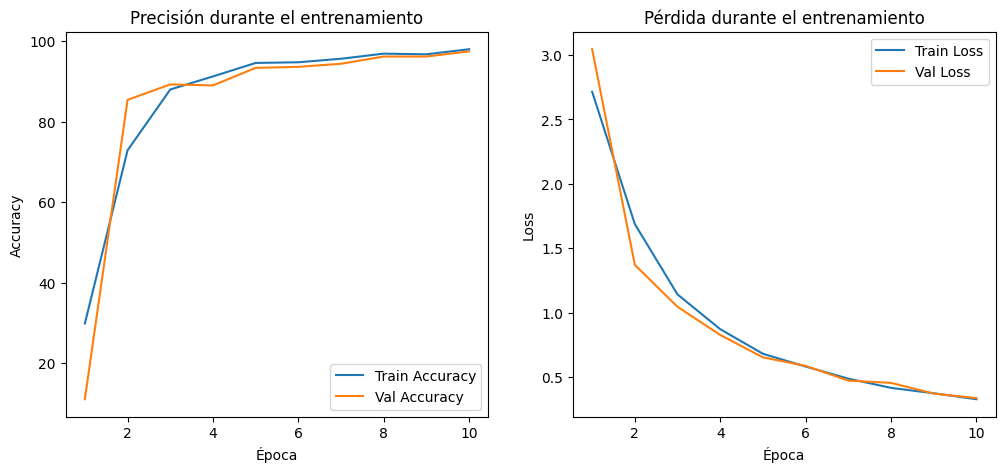

In [35]:

epochs_range = range(1, epochs+1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Val Accuracy')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [36]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 98.21%


Accuracy: 0.9821
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        15
           B       1.00      1.00      1.00        15
           C       1.00      1.00      1.00        15
           D       1.00      1.00      1.00        15
           E       0.94      1.00      0.97        15
           F       1.00      0.93      0.97        15
           G       1.00      0.93      0.97        15
           H       0.93      0.87      0.90        15
           I       1.00      1.00      1.00        15
           J       1.00      0.93      0.97        15
           K       1.00      1.00      1.00        15
           L       1.00      1.00      1.00        15
           M       0.94      1.00      0.97        15
           N       1.00      0.93      0.97        15
           O       1.00      0.93      0.97        15
           P       1.00      1.00      1.00        15
           Q       1.00      1.00      1.00        15
          

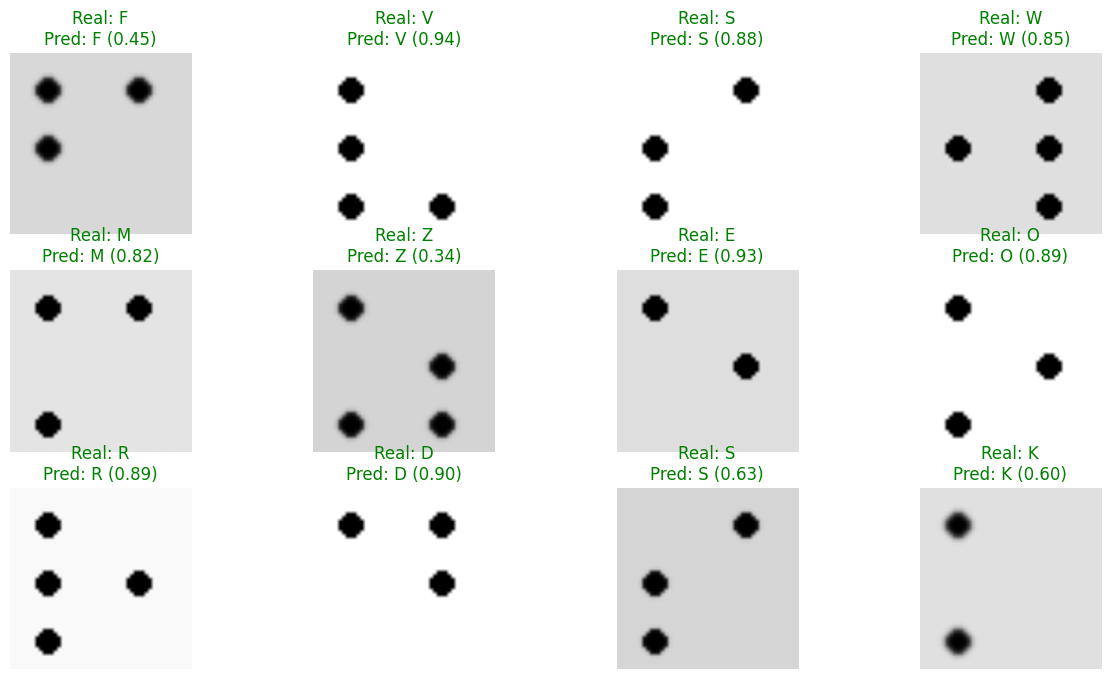

In [37]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

# Reporte completo
report = classification_report(y_true, y_pred, target_names=train_data.classes)
print(report)

def mostrar_predicciones_random(model, dataset, classes, num_images=12):
    model.eval()
    plt.figure(figsize=(15,8))

    indices = random.sample(range(len(dataset)), num_images)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, label = dataset[idx]

            image_tensor = image.unsqueeze(0).to(device)

            outputs = model(image_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, pred = torch.max(outputs, 1)

            img = image.permute(1,2,0).numpy()
            img = (img * 0.5) + 0.5

            real = classes[label]
            pred_label = classes[pred.item()]
            conf = probs[0][pred.item()].item()

            color = 'green' if real == pred_label else 'red'

            plt.subplot(3,4,i+1)
            plt.imshow(img)
            plt.title(f"Real: {real}\nPred: {pred_label} ({conf:.2f})", color=color)
            plt.axis('off')

    plt.show()

mostrar_predicciones_random(model, test_data, train_data.classes)

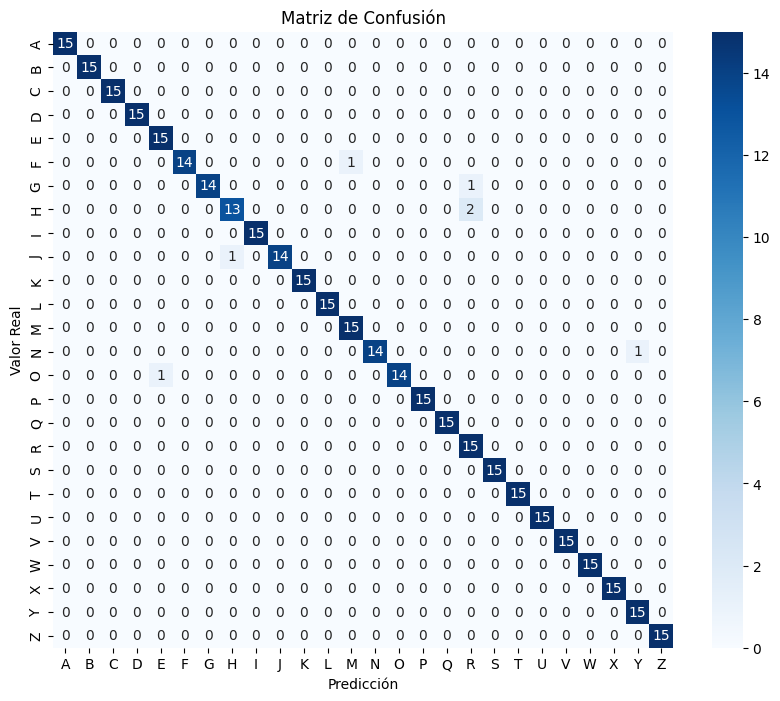

In [38]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=train_data.classes,
            yticklabels=train_data.classes)

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')

plt.show()